In [1]:
import numpy as np
from scipy.optimize import minimize
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
from cycler import cycler
%config InlineBackend.figure_format='retina'
from matplotlib import cm, colors

In [3]:
plt.rcParams['figure.facecolor'] = 'w'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif']= ['Arial'] 
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['grid.color'] = '#c8c8cb'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 1.5
plt.rcParams['xtick.major.size'] = 1.75
plt.rcParams['ytick.major.size'] = 1.75
plt.rcParams['xtick.major.width'] = 0.4
plt.rcParams['ytick.major.width'] = 0.4
plt.rcParams['xtick.minor.size'] = 1.4
plt.rcParams['ytick.minor.size'] = 1.4
plt.rcParams['xtick.minor.width'] = 0.3
plt.rcParams['ytick.minor.width'] = 0.3
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['font.size'] = 9
plt.rcParams['legend.title_fontsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['figure.figsize'] = [80/25.4,60/25.4] # 80mm x 60mm
plt.rcParams['figure.dpi'] = 200
plt.rcParams['axes.grid'] = False
plt.rcParams['pcolor.shading'] = 'nearest'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] =  True
plt.rcParams['ytick.right'] =  True
plt.rcParams['axes.xmargin'] = 0.0
plt.rcParams['legend.loc'] = 'upper left'
plt.rcParams['savefig.transparent']=True
plt.rcParams['text.usetex'] = False
plt.rcParams['axes.prop_cycle']  = cycler(color=[
'#005AFF',
'#FF4B00',
'#03AF7A',
'#990099',
'#F6AA00'])

In [4]:
def calc_offset(state):
    def amplitude_fluctuation(offset,state):
        state_offset_subtracted = ((state[0]-offset)) + 1j*(state[1]-offset)
        return np.sum(np.abs(np.diff(np.abs(state_offset_subtracted))))
        
    offset_opt = minimize(amplitude_fluctuation,0.5,args=(state,)).x
    
    offsets = np.linspace(0.45,0.52,101)
    fluctuatuations = np.array([amplitude_fluctuation(_offset,state) for _offset in offsets])
    plt.plot(offsets,fluctuatuations)
    # plt.vlines([offset],0,25,ls='--',lw=0.5,color='k',label='mean')
    plt.vlines([offset_opt],0,25,ls='--',lw=0.5,color='r',label='optimal')
    plt.ylim([0,fluctuatuations.max()])
    plt.xlabel('Offset in qubit measurement result')
    plt.ylabel('Total amplitude fluctuation')
    plt.legend()
    plt.show()
    return offset_opt

def plot_XY_trajectry(times,state,offset):
    plt.scatter(2*state[0]-1,2*state[1]-1,c=cm.viridis(np.linspace(0,1,len(state[0]))))
    plt.plot(2*offset-1,2*offset-1,'+',ms=5)
    plt.gca().set_aspect('equal')
    plt.xlim([-1,1])
    plt.ylim([-1,1])
    plt.grid()
    plt.xlabel(r'$\langle X\rangle$')
    plt.ylabel(r'$\langle Y\rangle$')
    
    plt.gcf().colorbar(cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=times[-1]*1e9), cmap=cm.viridis),
                 ax=plt.gca(), orientation='vertical', label='Time (ns)')
    plt.show()

def calc_detuning(state,offset,dt=1e-9):
    qubit_state = ((state[0]-offset)) + 1j*(state[1]-offset)
    qubit_phase = np.unwrap(np.angle(qubit_state))
    detuning = np.diff(qubit_phase)/(2*np.pi)/dt
    return detuning

def plot_detuning(times,detuning,dt=1e-9,label=''):
    xpl = (times[:-1]+times[1:])/2*1e9
    ypl = detuning*1e-6
    plt.plot(xpl,ypl,'o-',lw=0.5,ms=1,label=label)
    plt.xlabel('Time (ns)')
    plt.ylabel(r'Detuning (MHz)')
    plt.xlim([0,None])

def calc_normalized_flux_amplitude(detuning):
    step_response_freq = detuning/np.average(detuning[-20:])
    step_response_flux = (step_response_freq)**0.5
    return step_response_flux

def plot_flux_amplitude(times,step_response_flux,label=''):
    xpl = (times[:-1]+times[1:])/2*1e9
    ypl = step_response_flux
    plt.plot(xpl,ypl,'o-',lw=0.5,ms=1,label=label)
    plt.xlabel('Time (ns)')
    plt.ylabel(r'Normalized flux amplitude')
    plt.xlim([0,None])

In [5]:
data_dir = r'./data2/2025-02-21/#194_12_Cryoscope_142204' # LF Eccosrob
ds = xr.open_dataset(data_dir+r'\ds.h5')
state1 = ds.state.to_numpy().squeeze().T
times1 = ds.time.to_numpy()*1e-9
data_dir = r'./data2/2025-02-21/#157_12_Cryoscope_133957' # new LPF
ds = xr.open_dataset(data_dir+r'\ds.h5')
state2 = ds.state.to_numpy().squeeze().T
times2 = ds.time.to_numpy()*1e-9

Text(0.5, 1.0, 'LF Eccosorb')

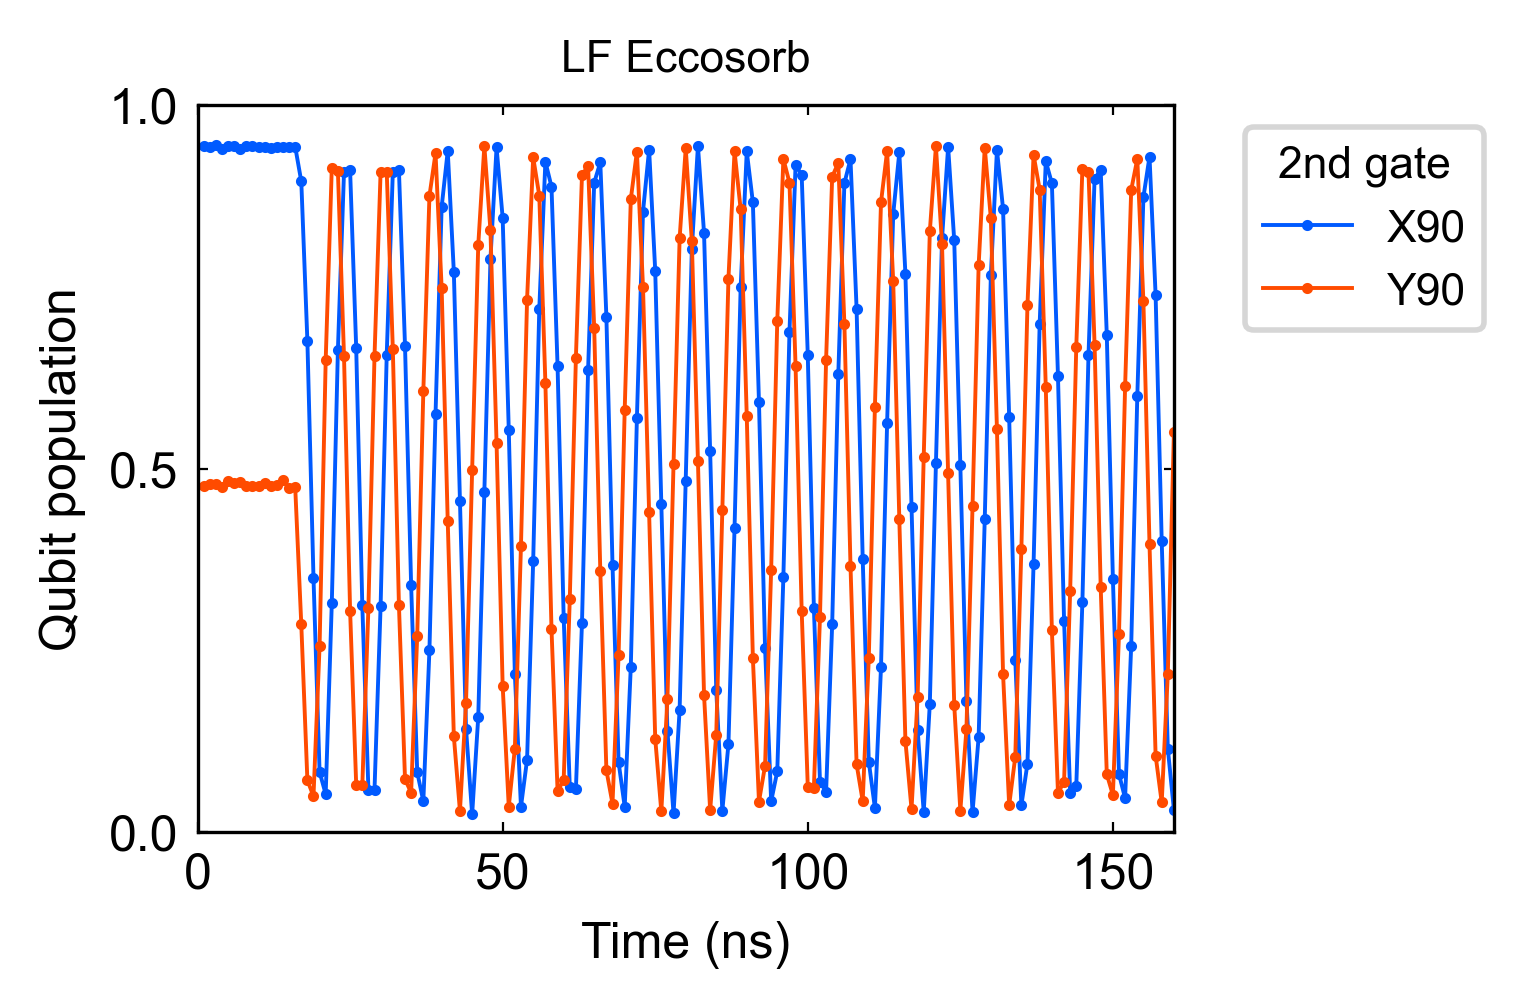

In [6]:
xpl = times1*1e9
plt.plot(xpl,state1[0],'-o',ms=1,lw=0.7, label='X90')
plt.plot(xpl,state1[1],'-o',ms=1,lw=0.7, label='Y90')
plt.legend(bbox_to_anchor=[1.05,1],title='2nd gate')
plt.xlabel('Time (ns)')
plt.ylabel('Qubit population')
plt.ylim([0,1])
plt.xlim([0,None])
plt.yticks([0,0.5,1])
plt.title('LF Eccosorb',fontsize=8)

Text(0.5, 1.0, 'New LPF')

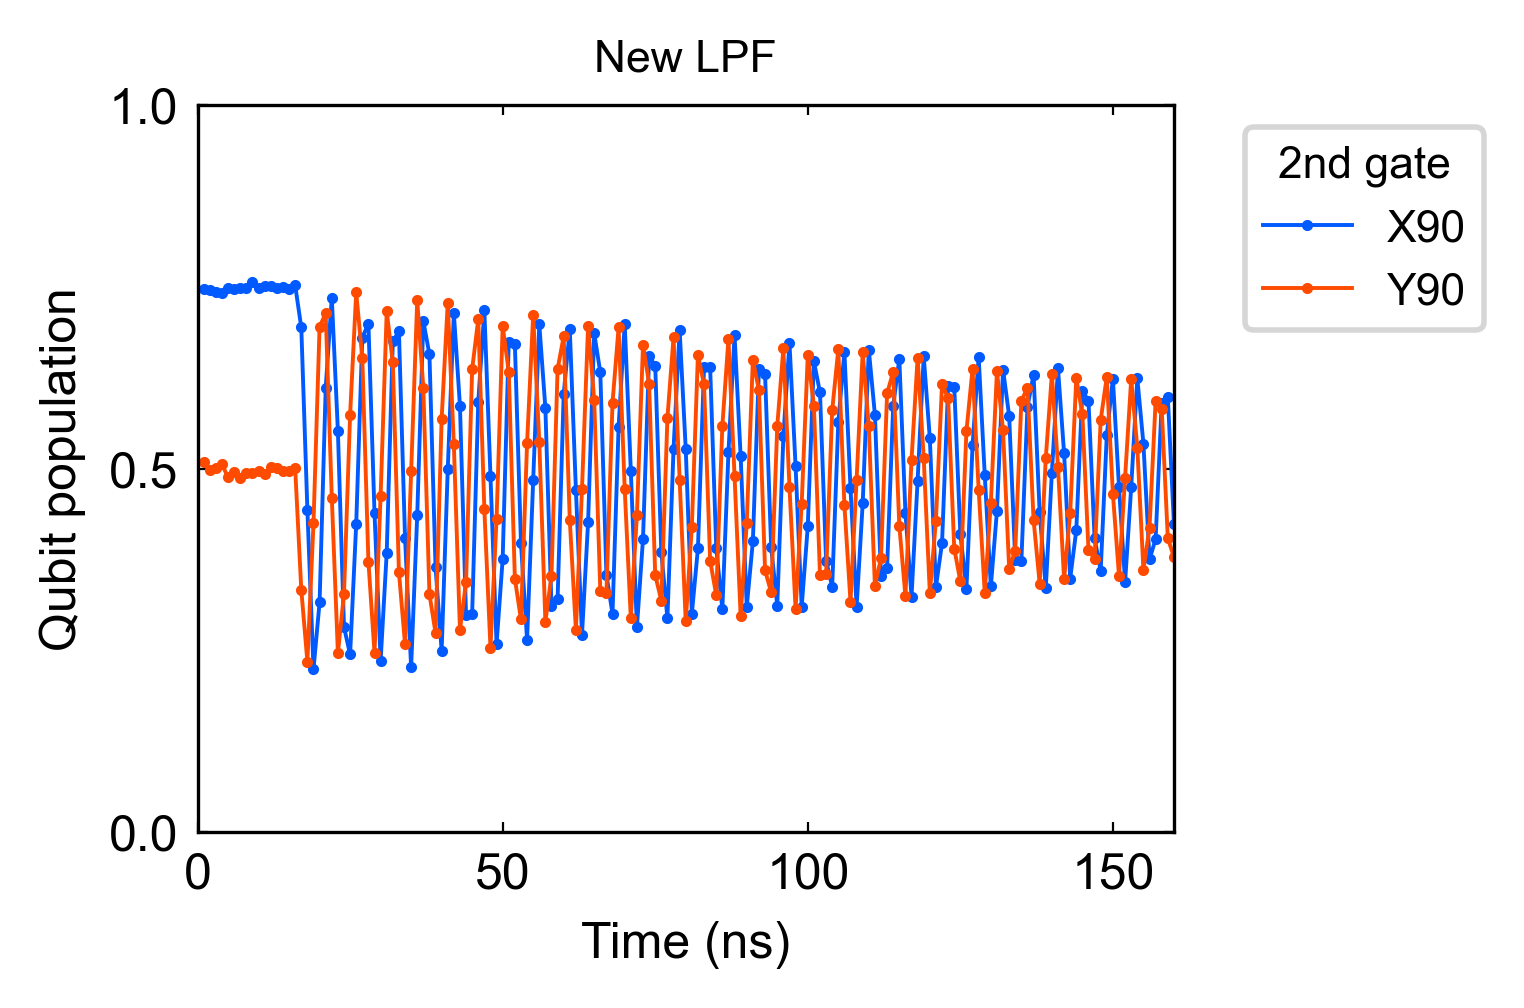

In [7]:
xpl = times2*1e9
plt.plot(xpl,state2[0],'-o',ms=1,lw=0.7, label='X90')
plt.plot(xpl,state2[1],'-o',ms=1,lw=0.7, label='Y90')
plt.legend(bbox_to_anchor=[1.05,1],title='2nd gate')
plt.xlabel('Time (ns)')
plt.ylabel('Qubit population')
plt.ylim([0,1])
plt.xlim([0,None])
plt.yticks([0,0.5,1])
plt.title('New LPF',fontsize=8)
# plt.xlim([0,20])

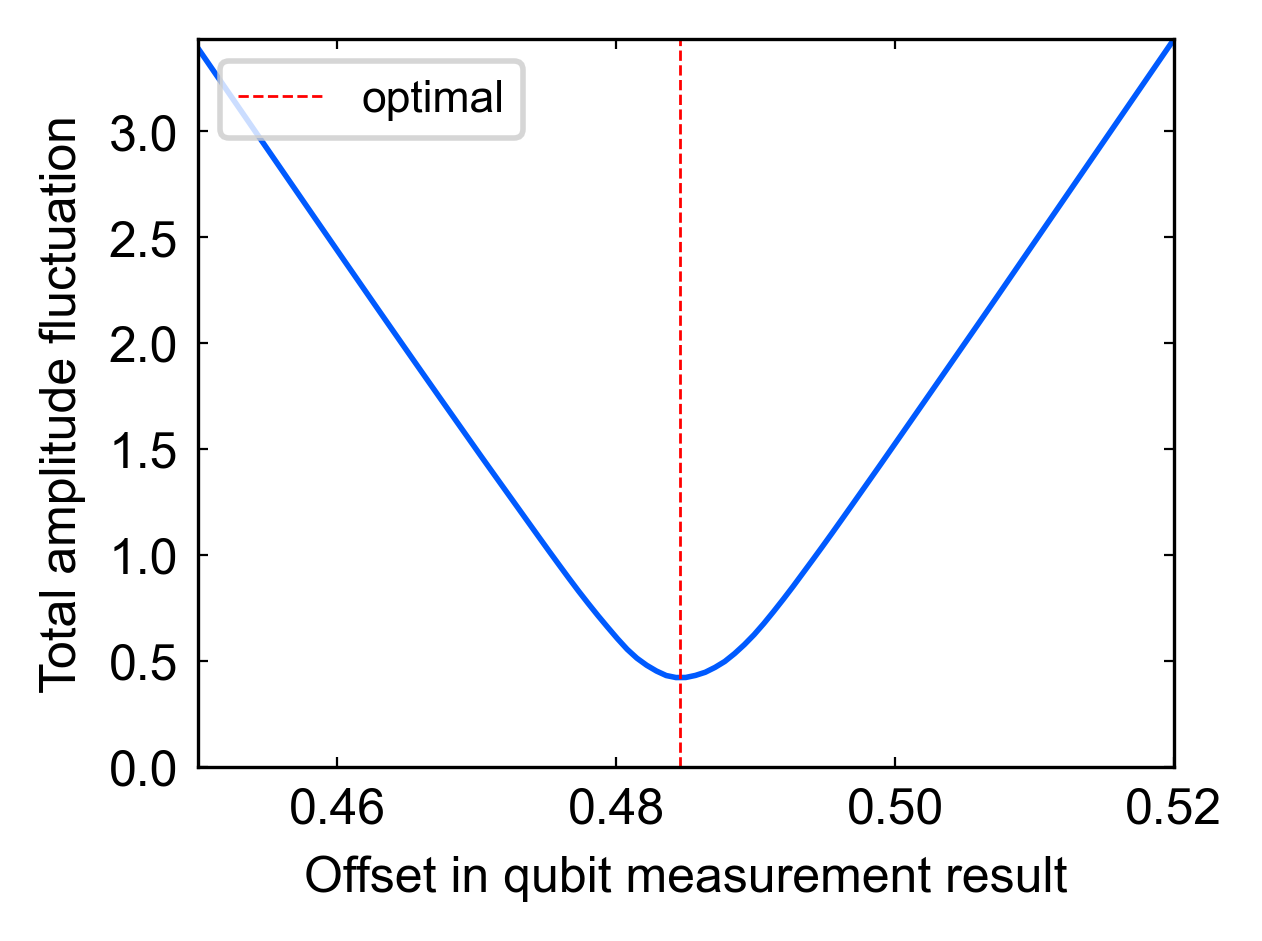

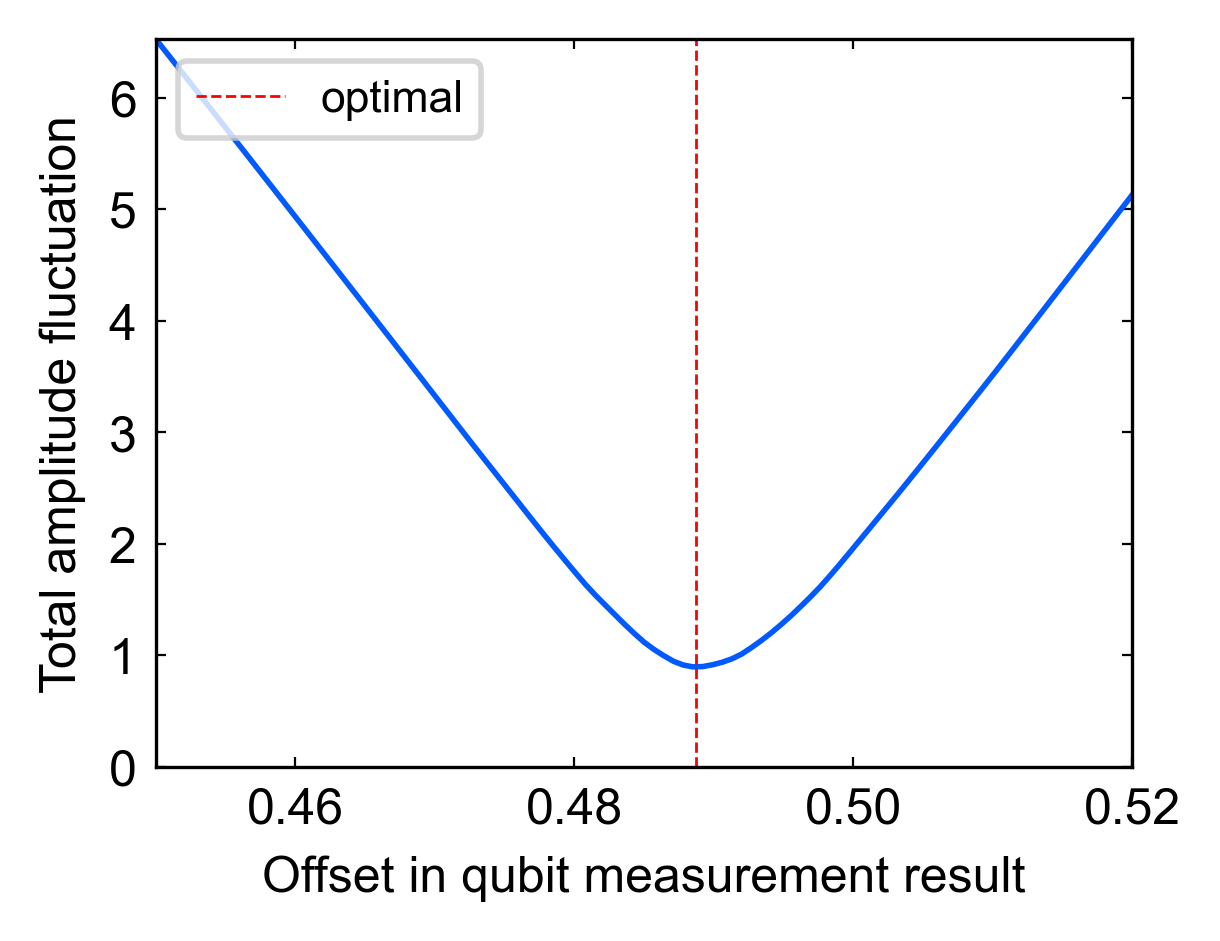

In [8]:
offset1 = calc_offset(state1)
offset2 = calc_offset(state2)

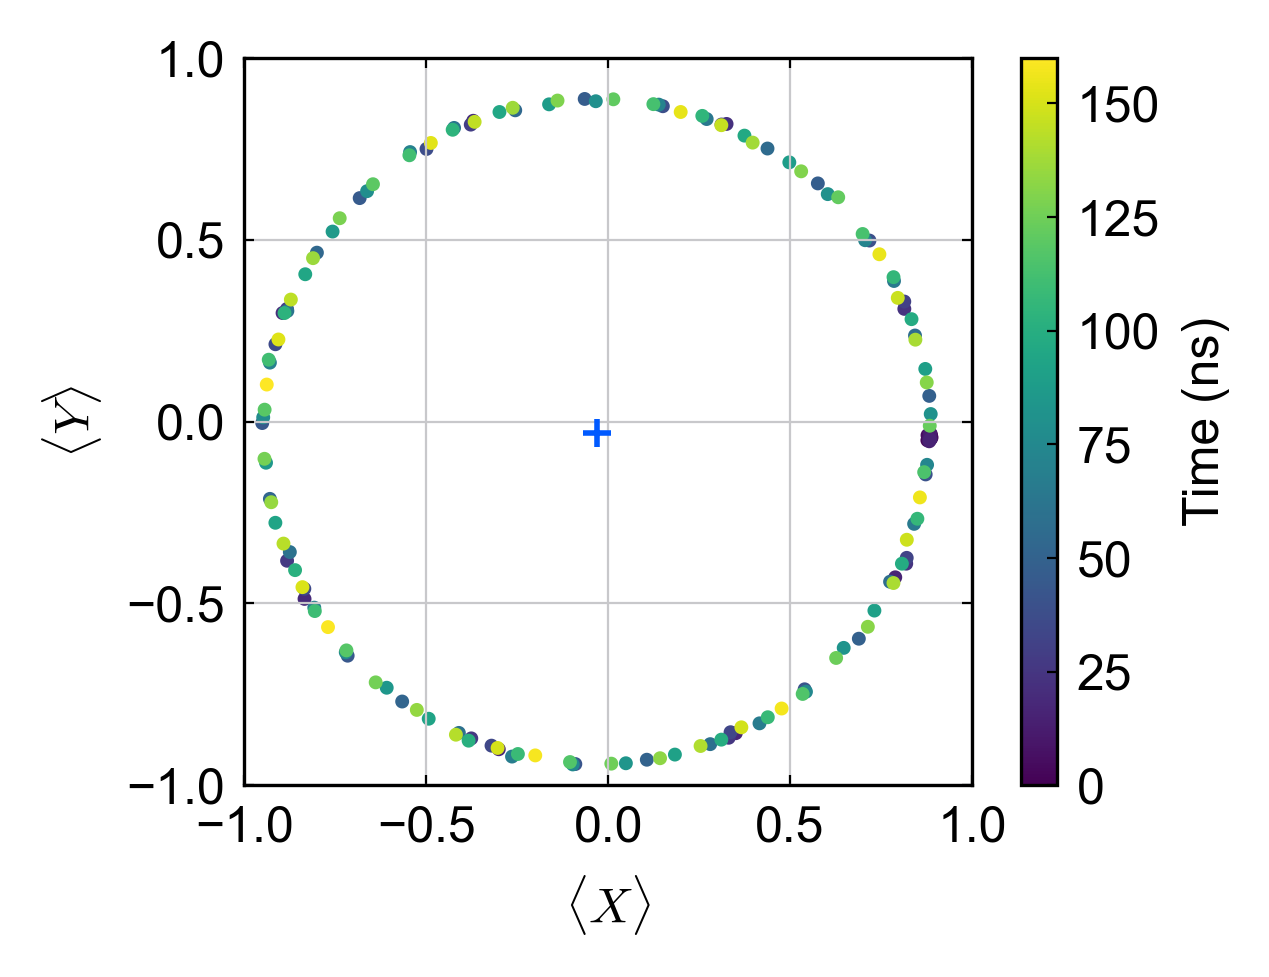

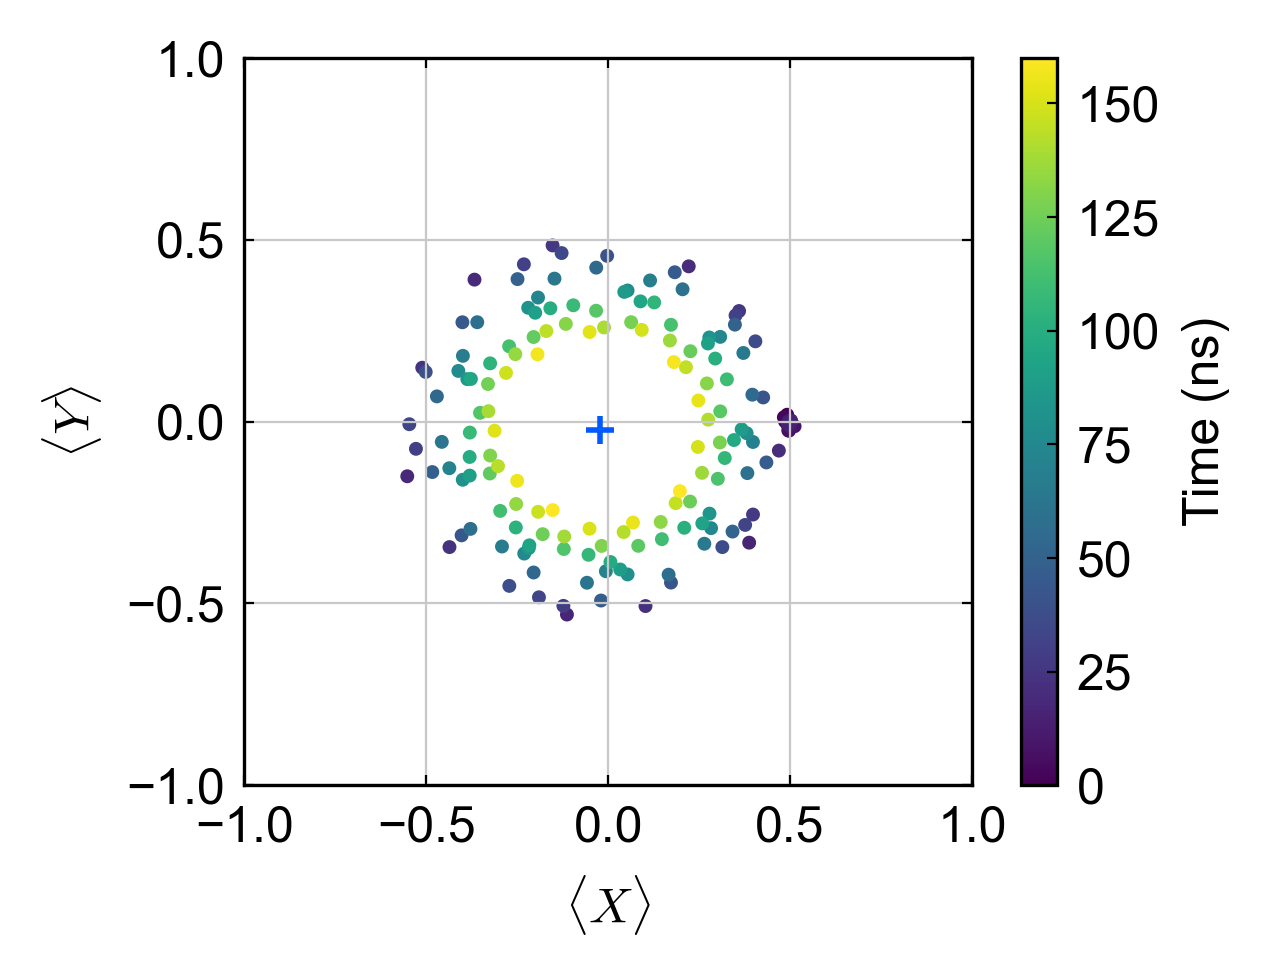

In [9]:
plot_XY_trajectry(times1,state1,offset1)
plot_XY_trajectry(times2,state2,offset2)

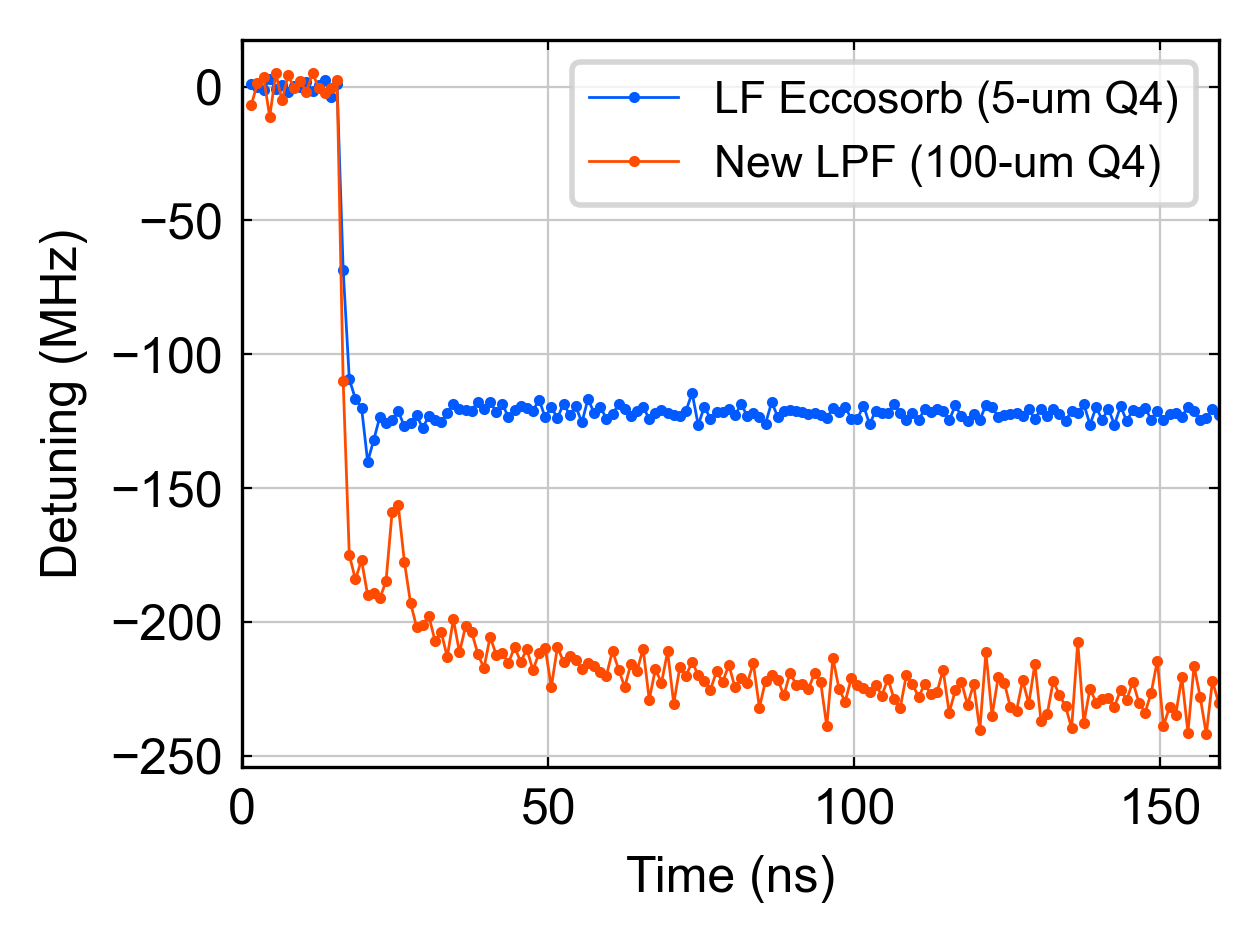

In [10]:
detuning1 = calc_detuning(state1,offset1,dt=1e-9)
detuning2 = calc_detuning(state2,offset2,dt=1e-9)

plot_detuning(times1,detuning1,label='LF Eccosorb (5-um Q4)')
plot_detuning(times2,detuning2,label='New LPF (100-um Q4)')
plt.grid(True)
plt.legend(loc='best')

C:\Users\daveh\AppData\Local\Temp\ipykernel_23140\1760755103.py:50: RuntimeWarning: invalid value encountered in sqrt
  step_response_flux = (step_response_freq)**0.5


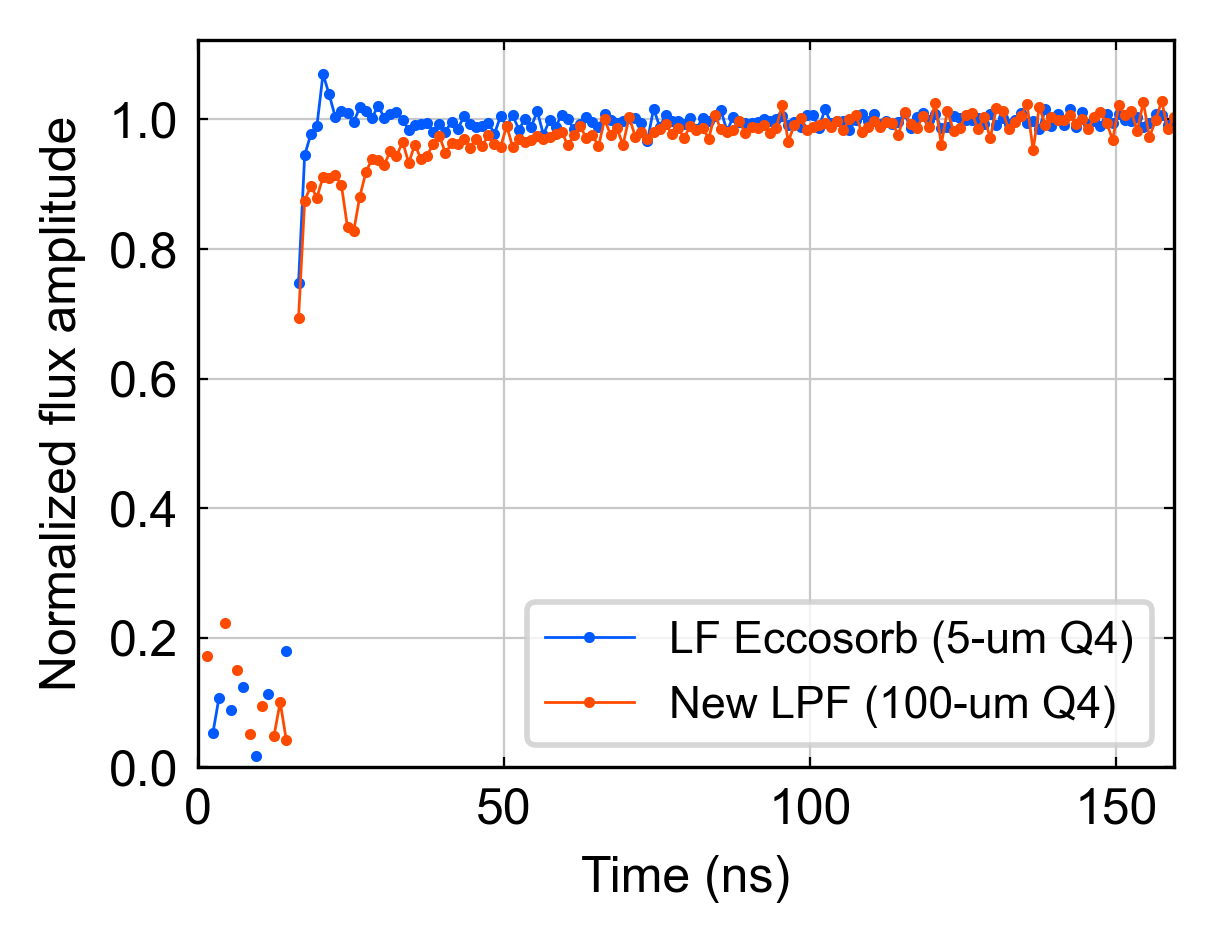

In [11]:
flux1 = calc_normalized_flux_amplitude(detuning1)
flux2 = calc_normalized_flux_amplitude(detuning2)

plot_flux_amplitude(times1,flux1,label='LF Eccosorb (5-um Q4)')
plot_flux_amplitude(times2,flux2,label='New LPF (100-um Q4)')
plt.grid(True)
plt.ylim([0,None])
plt.legend(loc='best')